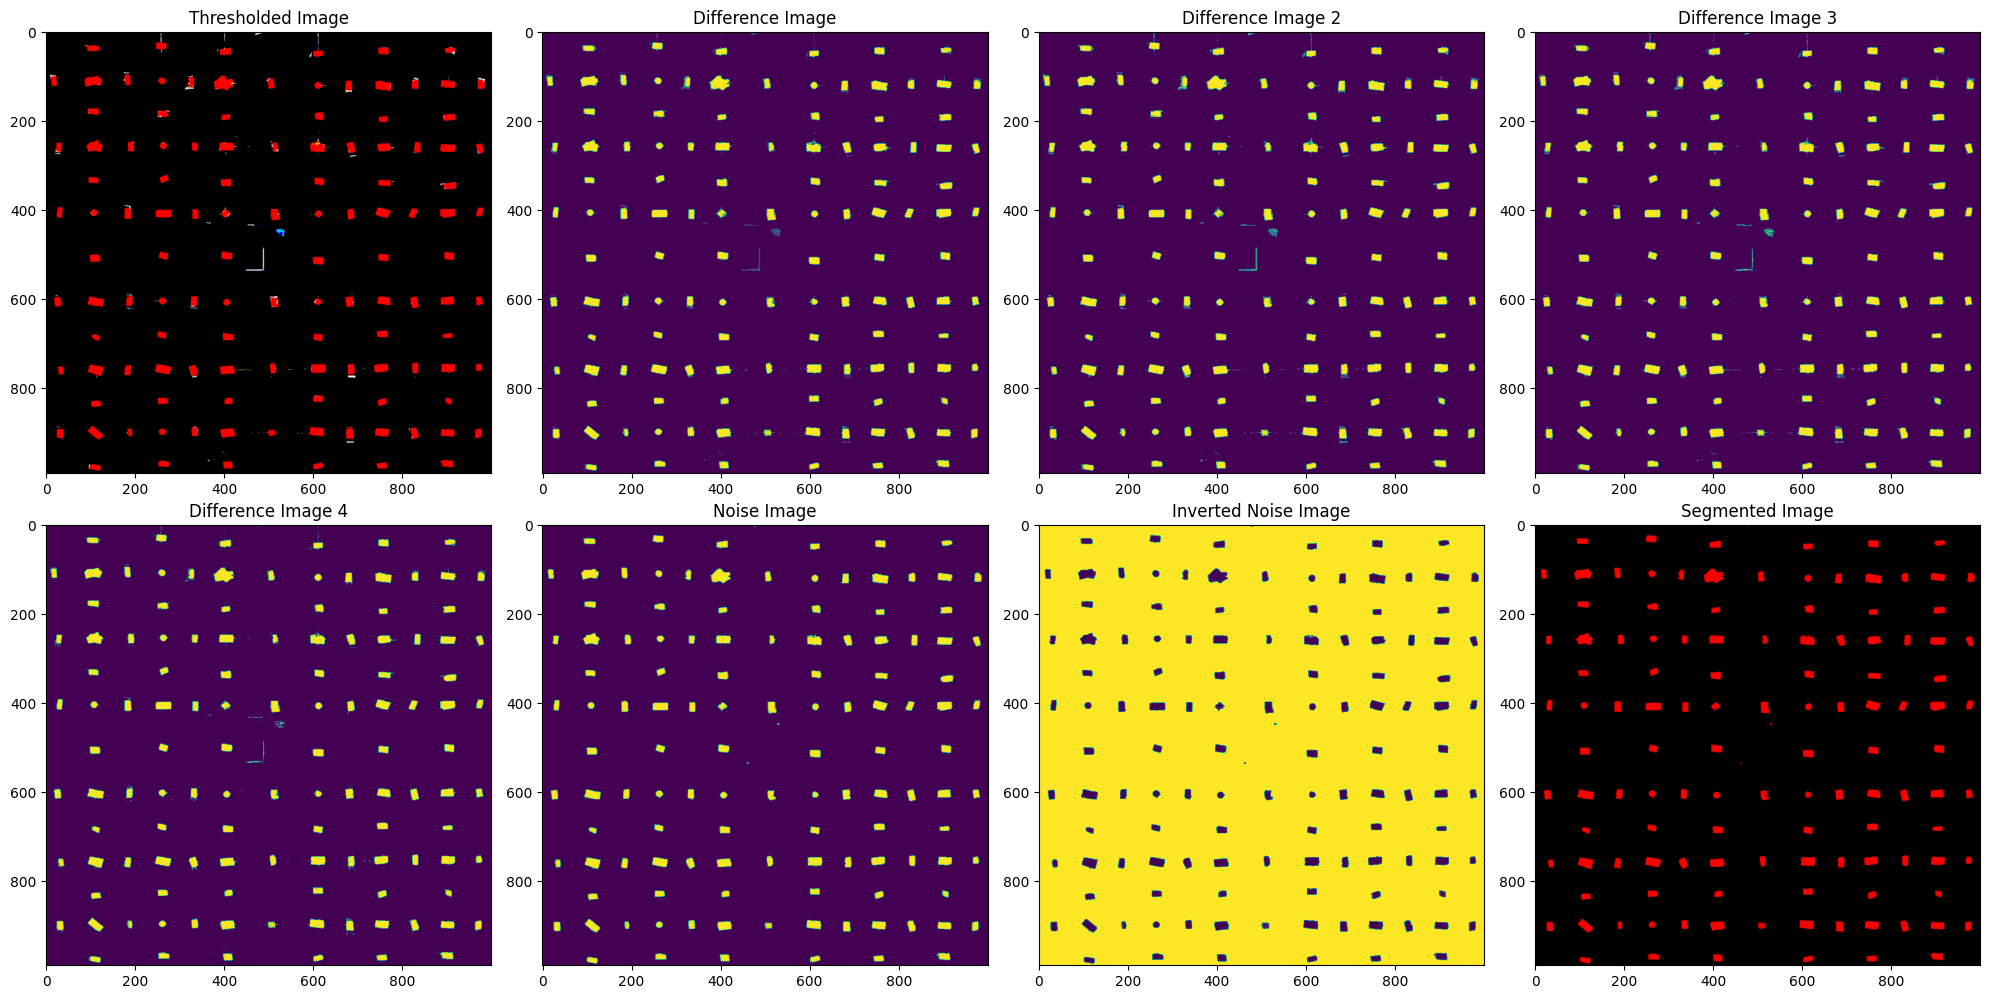

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def get_threshold_values(cropped_frame, threshold1, threshold2):

    thresh_indices = cropped_frame > threshold1
    threshold = thresh_indices*cropped_frame

    r_channel = threshold[:, :, 0]
    g_channel = threshold[:, :, 1]
    b_channel = threshold[:, :, 2]
    diff = r_channel-g_channel-b_channel ## pixels that have higher reds than greens and blues
    diff2 = diff-g_channel-b_channel
    diff3 = diff2-g_channel-b_channel
    if threshold2 == 0:
        diff4 = diff3
    else:
        diff4 = diff3*(diff3>threshold2)

    kernel = cv.getStructuringElement(cv.MORPH_RECT, (2, 2))
    noise = cv.morphologyEx(diff4, cv.MORPH_OPEN, kernel, iterations=2)

    inv = np.invert(noise)
    seg_img = np.array([noise.T, 0*inv.T, 0*inv.T]).T

    plt.figure(figsize=(20, 10))
    plt.subplot(241)
    plt.imshow(threshold)
    plt.title("Thresholded Image")
    plt.subplot(242)
    plt.imshow(diff)
    plt.title("Difference Image")
    plt.subplot(243)
    plt.imshow(diff2)
    plt.title("Difference Image 2")
    plt.subplot(244)
    plt.imshow(diff3)
    plt.title("Difference Image 3")
    plt.subplot(245)
    plt.imshow(diff4)
    plt.title("Difference Image 4")
    plt.subplot(246)
    plt.imshow(noise)
    plt.title("Noise Image")
    plt.subplot(247)
    plt.imshow(inv)
    plt.title("Inverted Noise Image")
    plt.subplot(248)
    plt.imshow(seg_img)
    plt.title("Segmented Image")
    plt.tight_layout()
    plt.show()

    keep = input(f"Do you want to keep these threshold values ({threshold1, threshold2})? (y/n): ")
    if keep == "n":
        threshold1 = int(input("Enter the new threshold1 value: "))
        threshold2 = int(input("Enter the new threshold2 value: "))
        threshold1, threshold2 = get_threshold_values(cropped_frame, threshold1, threshold2)
    else:
        threshold1 = threshold1
        threshold2 = threshold2

    return threshold1, threshold2

frame = cv.imread("C:/D/ABHYAAS/OneDrive - Virginia Tech/naughtonlab - Apoorva/BMSLab/Coding/fiber_network_project/fiber_network/Experiments/SAGE/6by6/Videos/2_2_25.MP4_frames/1.jpg")  # Replace with your image path
cropped_frame = frame[60:1050, 500:1500]  # Example crop, adjust as needed
cropped_frame = cv.cvtColor(cropped_frame, cv.COLOR_BGR2RGB)
threshold1 = 180
threshold2 = 180

threshold1, threshold2 = get_threshold_values(cropped_frame, threshold1, threshold2)

In [9]:
25/250

0.1